# Cluster stats

The purpose of this notebook is to analyze `STATE x leiden cluster` matrices for each accession.

## Data preparation

The data were produced by [`pipelines/cluster_stats.py`](../pipelines/cluster_stats.py) in run [`cluster_stats/clustered_20260509`](../output/cluster_stats/clustered_20260509). All aformentioned matrices were written to [`cluster_stats.json`](../output/cluster_stats/clustered_20260509/cluster_stats.json)

## Imports

In [5]:
import numpy as np
import pandas as pd
import xarray as xr
from scipy import stats
import matplotlib.pyplot as plt

## Construct `xarray.DataArray` object

In [6]:
from shared.repo import REPO_ROOT
from pathlib import Path
import json

CLUSTER_STATS_PATH = (
    REPO_ROOT / "output/cluster_stats/clustered_20260509/cluster_stats.json"
)

with open(CLUSTER_STATS_PATH) as f:
    _data = json.load(f)

samples    = list(_data.keys())
cell_types = sorted({ct for s in _data.values() for ct in s.keys()})
clusters   = sorted(
    {cl for s in _data.values() for ct in s.values() for cl in ct.keys()},
    key=int,
)

arr = np.zeros((len(samples), len(cell_types), len(clusters)), dtype=np.int32)

for i, sample in enumerate(samples):
    for j, cell_type in enumerate(cell_types):
        for k, cluster in enumerate(clusters):
            arr[i, j, k] = _data[sample].get(cell_type, {}).get(cluster, 0)

da = xr.DataArray(
    arr,
    dims=["accession", "STATE", "leiden_cluster"],
    coords={"accession": samples, "STATE": cell_types, "leiden_cluster": clusters},
    name="cell_count",
)

da

<xarray.DataArray 'cell_count' (accession: 765, STATE: 39, leiden_cluster: 106)> Size: 13MB
array([[[    1,     0,     0, ...,     0,     0,     0],
        [    8,   267,     5, ...,     0,     0,     0],
        [ 3468,    10,   903, ...,     0,     0,     0],
        ...,
        [    0,     0,     0, ...,     0,     0,     0],
        [    0,     0,     0, ...,     0,     0,     0],
        [    0,     0,     0, ...,     0,     0,     0]],

       [[11474,   256,  9593, ...,     0,     0,     0],
        [    0,     0,     0, ...,     0,     0,     0],
        [    0,     0,     0, ...,     0,     0,     0],
        ...,
        [    0,     0,     0, ...,     0,     0,     0],
        [    0,     0,     0, ...,     0,     0,     0],
        [    0,     0,     0, ...,     0,     0,     0]],

       [[ 6609,  1837,  1609, ...,     0,     0,     0],
        [    0,     0,     0, ...,     0,     0,     0],
        [    0,     0,     0, ...,     0,     0,     0],
        ...,
...
        [    0,     0,     0, ...,     0,     0,     0],
        [    0,     0,     0, ...,     0,     0,     0],
        [    0,     0,     0, ...,     0,     0,     0]],

       [[    0,     0,     0, ...,     0,     0,     0],
        [   20,   316,   781, ...,     0,     0,     0],
        [  135,   894,   558, ...,     0,     0,     0],
        ...,
        [    0,     0,     0, ...,     0,     0,     0],
        [    0,     0,     0, ...,     0,     0,     0],
        [    0,     0,     0, ...,     0,     0,     0]],

       [[    0,     0,     0, ...,     0,     0,     0],
        [   86,   196,   191, ...,     0,     0,     0],
        [ 1675,  3196,   633, ...,     0,     0,     0],
        ...,
        [    0,     0,     0, ...,     0,     0,     0],
        [    0,     0,     0, ...,     0,     0,     0],
        [    0,     0,     0, ...,     0,     0,     0]]],
      shape=(765, 39, 106), dtype=int32)
Coordinates:
  * accession       (accession) <U11 34kB 'ERX11662338' ... 'SRX9927818'
  * STATE           (STATE) <U52 8kB '' 'B cell' ... 'vein endothelial cell'
  * leiden_cluster  (leiden_cluster) <U3 1kB '0' '1' '2' ... '103' '104' '105'

## Stats
### Compute metrics across leiden clusters
- Shannon entropy
- Normalized Shannon entropy = `Shannon entropy / log(n_states)`

In [7]:
def _shannon_entropy(counts, dim):
    """Shannon entropy (bits) of a counts DataArray along `dim`."""
    totals = counts.sum(dim)
    p = (counts / totals).where(totals > 0)
    h = -(p * np.log2(p.where(p > 0))).sum(dim)
    return h.where(totals > 0)


def _normalized_entropy(counts, dim):
    """Normalized Shannon entropy: H / log2(k), where k = non-zero categories."""
    h = _shannon_entropy(counts, dim)
    k = (counts > 0).sum(dim).astype(float)
    return xr.where(k > 1, h / np.log2(k.where(k > 0)), xr.where(k == 1, 0.0, np.nan))

ds = xr.Dataset({
    "cell_count": da
})

ds["n_cells_leiden"] = ds["cell_count"].sum(dim="STATE")
ds["n_cells_STATE"] = ds["cell_count"].sum(dim="leiden_cluster")
ds["nse_leiden"] = _normalized_entropy(ds["cell_count"], dim="STATE")
ds["nse_STATE"] = _normalized_entropy(ds["cell_count"], dim="leiden_cluster")

### Confirm that the distribution of leiden cluster sizes is lognormal

lognormal fit:  mu = 5.564,  sigma = 1.228  (loc fixed at 0)
KS test vs fitted lognormal:  D = 0.0241,  p = 6.6e-05


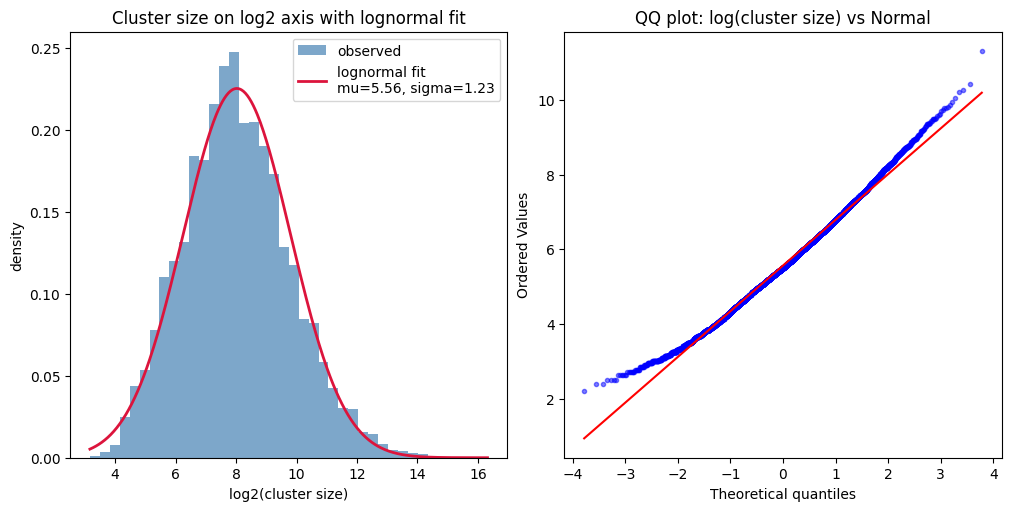

In [8]:
cluster_sizes = ds.n_cells_leiden.stack(point=("accession", "leiden_cluster"))
cluster_sizes = cluster_sizes.where(cluster_sizes > 0).dropna(dim="point")

sizes = cluster_sizes.values.astype(float)
log_sz = np.log2(sizes)

shape, loc, scale = stats.lognorm.fit(sizes, floc=0)
mu, sigma = np.log(scale), shape
print(f"lognormal fit:  mu = {mu:.3f},  sigma = {sigma:.3f}  (loc fixed at 0)")

ks_stat, ks_p = stats.kstest(sizes, "lognorm", args=(shape, loc, scale))
print(f"KS test vs fitted lognormal:  D = {ks_stat:.4f},  p = {ks_p:.3g}")

fig, (ax_hist, ax_qq) = plt.subplots(1, 2, figsize=(10, 5), layout="constrained")

ax_hist.hist(log_sz, bins=40, density=True, color="steelblue", alpha=0.7, label="observed")
xx = np.linspace(log_sz.min(), log_sz.max(), 400)
pdf_log = stats.norm.pdf(xx, loc=mu / np.log(2), scale=sigma / np.log(2))
ax_hist.plot(xx, pdf_log, color="crimson", lw=2, label=f"lognormal fit\nmu={mu:.2f}, sigma={sigma:.2f}")
ax_hist.set_xlabel("log2(cluster size)")
ax_hist.set_ylabel("density")
ax_hist.set_title("Cluster size on log2 axis with lognormal fit")
ax_hist.legend()

stats.probplot(np.log(sizes), dist="norm", plot=ax_qq)
ax_qq.set_title("QQ plot: log(cluster size) vs Normal")
ax_qq.get_lines()[0].set_markersize(3)
ax_qq.get_lines()[0].set_alpha(0.5)

plt.show()

## Plotting

### Distribution of entropy of leiden clusters across cluster size bins
ANOVA on bin means reported

one-way ANOVA: F = 86.9330,  p = 1.956e-55


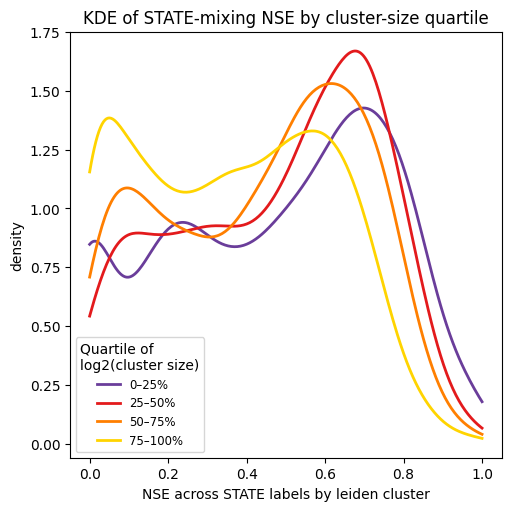

In [9]:
paired = xr.Dataset({
    "nse": ds.nse_leiden,
    "n_cells": ds.n_cells_leiden,
}).stack(point=("accession", "leiden_cluster")).dropna(dim="point")

nse_vals = paired["nse"].values
log_sz = np.log2(np.maximum(paired["n_cells"].values.astype(float), 1.0))

bins = pd.qcut(log_sz, q=4, duplicates="drop")
quartiles = ["0–25%", "25–50%", "50–75%", "75–100%"]
fig, ax = plt.subplots(1, 1, figsize=(5, 5), layout="constrained", sharex=True)

n_cats = len(bins.categories)
if n_cats == 4:
    palette = ["#6a3d9a", "#e31a1c", "#ff7f00", "#ffd400"]
else:
    palette = [plt.cm.plasma(t) for t in np.linspace(0.1, 0.9, max(n_cats, 1))]

bin_codes = np.asarray(bins.codes)
groups = []
labels = []
for idx, interval in enumerate(bins.categories):
    mask = bin_codes == idx
    sub = nse_vals[mask]
    sub = sub[np.isfinite(sub)]
    groups.append(sub)
    labels.append(f"[{interval.left:.1f}, {interval.right:.1f}]n={mask.sum():d}")

for idx, (sub, interval) in enumerate(zip(groups, bins.categories)):
    if sub.size < 2:
        continue
    kde = stats.gaussian_kde(sub)
    pad = max((sub.max() - sub.min()) * 0.08, 0.02)
    lo, hi = max(0.0, sub.min() - pad), min(1.0, sub.max() + pad)
    xx = np.linspace(lo, hi, 256)
    ax.plot(xx, kde(xx), color=palette[idx], lw=2,
             label=f"log2(size) [{interval.left:.2f}, {interval.right:.2f}]  n={sub.size:d}")
ax.set_title("KDE of STATE-mixing NSE by cluster-size quartile")
ax.set_xlabel("NSE across STATE labels by leiden cluster")
ax.set_ylabel("density")
ax.legend(labels=quartiles[:len(groups)], loc="best", fontsize="small", title="Quartile of\nlog2(cluster size)")

f_stat, p_anova = stats.f_oneway(*groups)

print(f"one-way ANOVA: F = {f_stat:.4f},  p = {p_anova:.3e}")
plt.show()

### Normalized Shannon entropy vs cluster size

Notice how dense the points at NSE=0 are. This tells us that lots of leiden clusters contain only one STATE label

Linear regressor is plotted, along with a LOWESS regressor to get a sense for any potential non-linearity in the data

global slope = -1.0177 ± 0.0712 (SE),  R² = 0.0225,  p = 7.616e-46


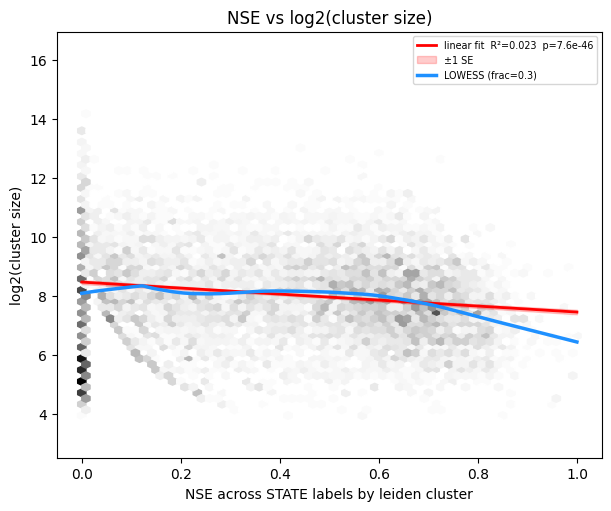

In [10]:
from statsmodels.nonparametric.smoothers_lowess import lowess

paired = xr.Dataset({
    "nse": ds.nse_leiden,
    "n_cells": ds.n_cells_leiden,
}).stack(point=("accession", "leiden_cluster")).dropna(dim="point")

x = paired["nse"].values
y = np.log2(paired["n_cells"].values.astype(float))

fig, ax = plt.subplots(1, 1, figsize=(6, 5), layout="constrained")

ax.hexbin(x, y, gridsize=60, cmap="Greys", mincnt=1)

regressor = stats.linregress(x=x, y=y)
xx = np.linspace(x.min(), x.max(), 300)
yy = regressor.intercept + regressor.slope * xx
se_band = regressor.intercept_stderr + regressor.stderr * np.abs(xx - x.mean())
ax.plot(xx, yy, color="red", lw=2,
        label=f"linear fit  R²={regressor.rvalue**2:.3f}  p={regressor.pvalue:.1e}")
ax.fill_between(xx, yy - se_band, yy + se_band, color="red", alpha=0.2, label="±1 SE")

smooth = lowess(y, x, frac=0.3, return_sorted=True)
ax.plot(smooth[:, 0], smooth[:, 1], color="dodgerblue", lw=2.5, label="LOWESS (frac=0.3)")

ax.set_xlabel("NSE across STATE labels by leiden cluster")
ax.set_ylabel("log2(cluster size)")
ax.set_title("NSE vs log2(cluster size)")
ax.legend(fontsize="x-small", loc="upper right")

print(f"global slope = {regressor.slope:.4f} ± {regressor.stderr:.4f} (SE),  R² = {regressor.rvalue**2:.4f},  p = {regressor.pvalue:.3e}")
plt.show()


In [11]:
# ds["entropy_over_clusters"] = _shannon_entropy(ds["cell_count"], dim="leiden_cluster")

In [12]:
# TODO: compute entropy & kl divergence of clusters across states, bin, visualize
# simply involves making a new "rectangle", can go to pandas with to_pandas method

In [13]:
ds

<xarray.Dataset> Size: 14MB
Dimensions:         (accession: 765, STATE: 39, leiden_cluster: 106)
Coordinates:
  * accession       (accession) <U11 34kB 'ERX11662338' ... 'SRX9927818'
  * STATE           (STATE) <U52 8kB '' 'B cell' ... 'vein endothelial cell'
  * leiden_cluster  (leiden_cluster) <U3 1kB '0' '1' '2' ... '103' '104' '105'
Data variables:
    cell_count      (accession, STATE, leiden_cluster) int32 13MB 1 0 0 ... 0 0
    n_cells_leiden  (accession, leiden_cluster) int64 649kB 3501 279 917 ... 0 0
    n_cells_STATE   (accession, STATE) int64 239kB 20 771 4796 375 0 ... 0 0 0 0
    nse_leiden      (accession, leiden_cluster) float64 649kB 0.03252 ... nan
    nse_STATE       (accession, STATE) float64 239kB 0.2864 0.626 ... nan nan

In [14]:
ds["entropy_over_leiden"] = _shannon_entropy(ds["cell_count"], dim="leiden_cluster")
ds["entropy_over_STATE"] = _shannon_entropy(ds["cell_count"], dim="STATE")
ds["n_cells_leiden"] = ds["cell_count"].sum(dim="STATE")
ds["n_cells_STATE"] = ds["cell_count"].sum(dim="leiden_cluster")
ds["nse_leiden"] = _normalized_entropy(ds["cell_count"], dim="leiden_cluster")
ds["nse_STATE"] = _normalized_entropy(ds["cell_count"], dim="leiden_cluster")

In [15]:
ds

<xarray.Dataset> Size: 15MB
Dimensions:              (accession: 765, STATE: 39, leiden_cluster: 106)
Coordinates:
  * accession            (accession) <U11 34kB 'ERX11662338' ... 'SRX9927818'
  * STATE                (STATE) <U52 8kB '' ... 'vein endothelial cell'
  * leiden_cluster       (leiden_cluster) <U3 1kB '0' '1' '2' ... '104' '105'
Data variables:
    cell_count           (accession, STATE, leiden_cluster) int32 13MB 1 0 ... 0
    n_cells_leiden       (accession, leiden_cluster) int64 649kB 3501 279 ... 0
    n_cells_STATE        (accession, STATE) int64 239kB 20 771 4796 ... 0 0 0
    nse_leiden           (accession, STATE) float64 239kB 0.2864 0.626 ... nan
    nse_STATE            (accession, STATE) float64 239kB 0.2864 0.626 ... nan
    entropy_over_leiden  (accession, STATE) float64 239kB 0.2864 1.984 ... nan
    entropy_over_STATE   (accession, leiden_cluster) float64 649kB 0.09131 .....

In [16]:
ds.nse_leiden

<xarray.DataArray 'nse_leiden' (accession: 765, STATE: 39)> Size: 239kB
array([[0.28639696, 0.62597693, 0.3862558 , ...,        nan,        nan,
               nan],
       [0.79103795,        nan,        nan, ...,        nan,        nan,
               nan],
       [0.74111322,        nan,        nan, ...,        nan,        nan,
               nan],
       ...,
       [       nan, 0.        , 0.        , ...,        nan,        nan,
               nan],
       [       nan, 0.58933175, 0.74833382, ...,        nan,        nan,
               nan],
       [       nan, 0.61947789, 0.49493266, ...,        nan,        nan,
               nan]], shape=(765, 39))
Coordinates:
  * accession  (accession) <U11 34kB 'ERX11662338' ... 'SRX9927818'
  * STATE      (STATE) <U52 8kB '' 'B cell' ... 'vein endothelial cell'

Text(0, 0.5, 'nse_STATE')

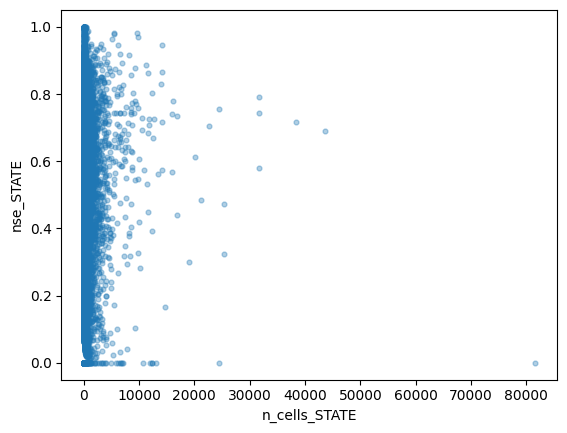

In [17]:
paired = xr.Dataset({"x": ds.n_cells_STATE, "y": ds.nse_STATE})
flat = paired.stack(point=("accession", "STATE"))
valid = flat.dropna(dim="point")

fig, ax = plt.subplots()
ax.scatter(valid["x"].values, valid["y"].values, alpha=0.35, s=12)
ax.set_xlabel("n_cells_STATE")
ax.set_ylabel("nse_STATE")